<a href="https://colab.research.google.com/github/SergeiVKalinin/Image_Reconstruction/blob/main/notebooks/grayrecon/00_synthetic_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GrayRecon 00 — Synthetic Grayscale Data

This notebook demonstrates the common two-dimensional grayscale reconstruction
problems used by all GrayRecon methods:

1. field models;
2. structural motif models;
3. quasi-MD models.

GrayRecon images contain one scalar intensity per pixel and do not encode atomic
identity. Any point coordinates stored with a synthetic case are unlabeled
geometric construction data.

## Conventions

- Image shape: `(height, width)`
- Point coordinates: `(x, y)`
- Image indexing: `image[y, x]`
- Mask value `True`: observed pixel
- Mask value `False`: missing pixel

In [2]:
from pathlib import Path
import os

REPO_URL = "https://github.com/SergeiVKalinin/Image_Reconstruction.git"
REPO_DIR = Path("/content/Image_Reconstruction")

if (REPO_DIR / ".git").exists():
    os.chdir(REPO_DIR)
    !git pull --ff-only origin main
else:
    !git clone --branch main --single-branch {REPO_URL} {REPO_DIR}
    os.chdir(REPO_DIR)

print("Working directory:", Path.cwd())

Cloning into '/content/Image_Reconstruction'...
remote: Enumerating objects: 124, done.
remote: Counting objects: 100% (124/124), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 124 (delta 47), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (124/124), 43.19 KiB | 1.88 MiB/s, done.
Resolving deltas: 100% (47/47), done.
Working directory: /content/Image_Reconstruction


In [3]:
!python -m pip install -q -e .

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for image-reconstruction (pyproject.toml) ... done


In [4]:
!find . -maxdepth 3 -type f | sort

./evaluation/__init__.py
./evaluation/README.md
./.git/config
./.git/description
./.git/HEAD
./.git/hooks/applypatch-msg.sample
./.git/hooks/commit-msg.sample
./.git/hooks/fsmonitor-watchman.sample
./.git/hooks/post-update.sample
./.git/hooks/pre-applypatch.sample
./.git/hooks/pre-commit.sample
./.git/hooks/pre-merge-commit.sample
./.git/hooks/prepare-commit-msg.sample
./.git/hooks/pre-push.sample
./.git/hooks/pre-rebase.sample
./.git/hooks/pre-receive.sample
./.git/hooks/push-to-checkout.sample
./.git/hooks/update.sample
./.gitignore
./.git/index
./.git/info/exclude
./.git/logs/HEAD
./.git/packed-refs
./grayrecon/field_models/__init__.py
./grayrecon/field_models/README.md
./grayrecon/__init__.py
./grayrecon/motifs/__init__.py
./grayrecon/motifs/README.md
./grayrecon/quasi_md/__init__.py
./grayrecon/quasi_md/README.md
./grayrecon/README.md
./grayrecon/synthetic/cases.py
./grayrecon/synthetic/__init__.py
./grayrecon/synthetic/masks.py
./grayrecon/synthetic/noise.py
./grayrecon/synthetic

In [5]:
import grayrecon
import visualization

from grayrecon.synthetic import (
    add_gaussian_noise,
    make_lattice_image,
    make_lattice_inpainting_case,
    make_lattice_outpainting_case,
)

from visualization import (
    show_grayrecon_case,
    show_image,
)

print("GrayRecon imported successfully.")
print("GrayRecon version:", grayrecon.__version__)

GrayRecon imported successfully.
GrayRecon version: 0.1.0


In [6]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120

Image shape: (128, 128)
Number of unlabeled points: 258


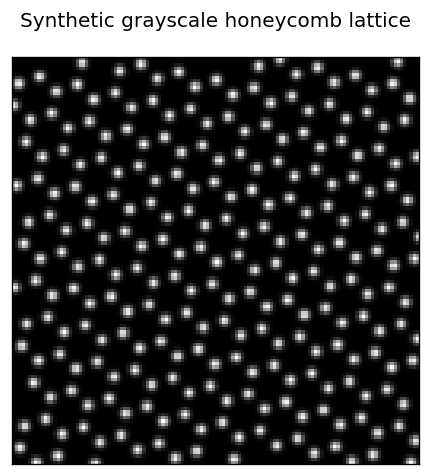

In [7]:
image, points = make_lattice_image(
    shape=(128, 128),
    lattice="honeycomb",
    spacing=7.0,
    rotation_degrees=12.0,
    sigma=1.1,
)

print("Image shape:", image.shape)
print("Number of unlabeled points:", len(points))

show_image(
    image,
    title="Synthetic grayscale honeycomb lattice",
    vmin=0.0,
    vmax=1.0,
)

plt.show()

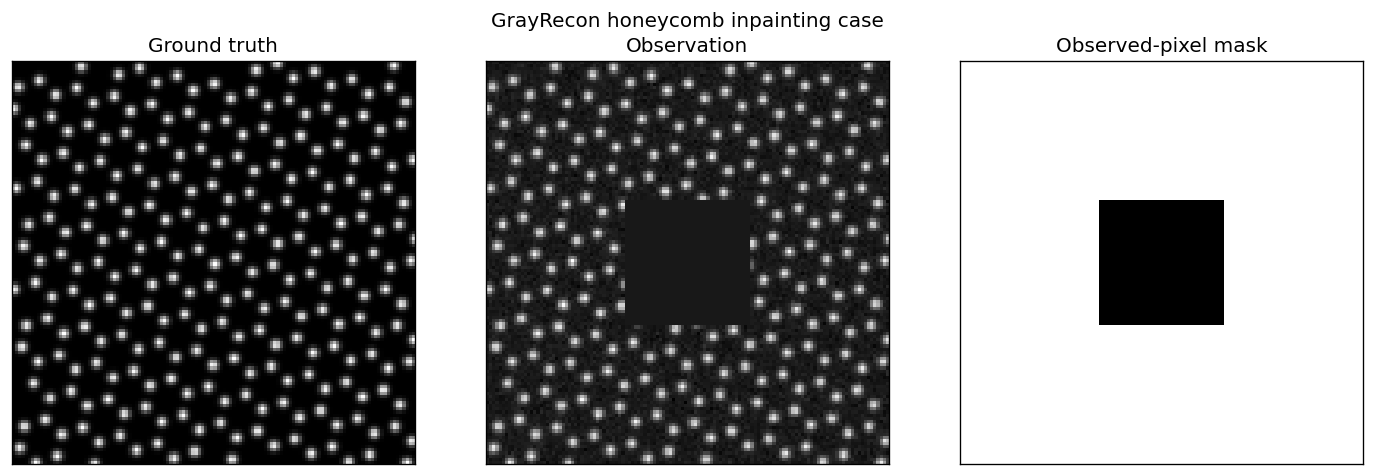

In [8]:
case = make_lattice_inpainting_case(
    shape=(128, 128),
    lattice="honeycomb",
    spacing=7.0,
    rotation_degrees=12.0,
    peak_sigma=1.1,
    missing_size=(40, 40),
    noise_sigma=0.03,
    seed=42,
    fill_value=0.0,
)

show_grayrecon_case(
    ground_truth=case.ground_truth,
    observation=case.observation,
    mask=case.mask,
    title="GrayRecon honeycomb inpainting case",
)

plt.show()